In [ ]:
import numpy as np
import copy
import gymnasium as gym
from gymnasium import spaces
from typing import Optional

class SchedulerEnv(gym.Env):
    def __init__(
        self,
        gender: int = 1,
        age: int = 25,
        height: float = 175.0,
        weight: float = 70.0,
        target_body_fat: float = 15.0,
        days_per_episode: int = 30,
        workloads: float = 1.5,
        sleep_duration: int = 8
    ):
        super().__init__()

        self.gender = gender
        self.age = age
        self.height = height
        self.weight = weight
        self.target_body_fat = target_body_fat
        self.days_per_episode = days_per_episode
        self.workloads = workloads
        self.sleep_duration = sleep_duration

        self.hours_per_day = 24
        self.scheduler = ["action"] * self.hours_per_day

        self.daily_meal_target = {
            "fiber": 34, #g
            "fat": 0.26, #ratio
            "carbs": 0.56, #ratio
            "protein": 0.18, #ratio
        }

        self.daily_total_targets = {
            "water": 3.7, #l
            "calcium": 1000, #mg
            "iron": 8, #mg
            "vitamin_c": 90 #mg
        }

        wake_up_hour = 6
        sleep_start = (wake_up_hour - self.sleep_duration) % 24
        if sleep_start < wake_up_hour:
            for i in range(sleep_start, wake_up_hour):
                self.scheduler[i] = 'sleep'
        else:
            for i in range(sleep_start, 24):
                self.scheduler[i] = 'sleep'
            for i in range(0, wake_up_hour):
                self.scheduler[i] = 'sleep'

        for start, end in [(10, 12), (13, 18)]:
            for i in range(start, end):
                self.scheduler[i] = 'work'

        # ====== State ======
        self.state = {
            "current_weight": self.weight,
            "current_bmi": self.weight / (self.height / 100) ** 2,
            "current_body_fat": 1.2 * (self.weight / (self.height / 100) ** 2)
                                + 0.23 * self.age
                                - 10.8 * self.gender
                                - 5.4,
            "current_hours": 0,
            "day_of_episode": 0,
            "time_since_last_meal": 0,
            "time_since_last_exercise": 0,
            "body_fat_history": [],
            "daily_calories_burned": 0.0,
            "daily_calories_intake": 0.0,
            "daily_calories": self.weight * 24,
            "daily_fiber_intake": 0.0,
            "daily_fat_intake": 0.0,
            "daily_carbs_intake": 0.0,
            "daily_protein_intake": 0.0,
            "daily_water_intake": 0.0,
            "daily_calcium_intake": 0.0,
            "daily_iron_intake": 0.0,
            "daily_vitamin_c_intake": 0.0
        }

        # ====== Spaces (Gymnasium API) ======
        self.action_space = spaces.Discrete(10)
        self.observation_space = spaces.Dict({
            "current_weight": spaces.Box(low=30.0, high=300.0, shape=(1,), dtype=np.float32),
            "current_bmi": spaces.Box(low=15.0, high=50.0, shape=(1,), dtype=np.float32),
            "current_body_fat": spaces.Box(low=5.0, high=50.0, shape=(1,), dtype=np.float32),
            "current_hours": spaces.Discrete(self.hours_per_day),
            "day_of_episode": spaces.Box(low=0, high=self.days_per_episode, shape=(1,), dtype=np.int32),
            "time_since_last_meal": spaces.Box(low=0, high=24, shape=(1,), dtype=np.int32),
            "time_since_last_exercise": spaces.Box(low=0, high=self.days_per_episode * 24, shape=(1,), dtype=np.int32),
            "daily_calories_burned": spaces.Box(low=0.0, high=4000.0, shape=(1,), dtype=np.float32),
            "daily_calories_intake": spaces.Box(low=0.0, high=4000.0, shape=(1,), dtype=np.float32),
            "daily_calories": spaces.Box(low=500.0, high=3000.0, shape=(1,), dtype=np.float32),
            "daily_fiber_intake": spaces.Box(low=0.0, high=50.0, shape=(1,), dtype=np.float32),
            "daily_fat_intake": spaces.Box(low=0.0, high=200.0, shape=(1,), dtype=np.float32),
            "daily_carbs_intake": spaces.Box(low=0.0, high=600.0, shape=(1,), dtype=np.float32),
            "daily_protein_intake": spaces.Box(low=0.0, high=300.0, shape=(1,), dtype=np.float32),
            "daily_water_intake": spaces.Box(low=0.0, high=10.0, shape=(1,), dtype=np.float32),
            "daily_calcium_intake": spaces.Box(low=0.0, high=3000.0, shape=(1,), dtype=np.float32),
            "daily_iron_intake": spaces.Box(low=0.0, high=50.0, shape=(1,), dtype=np.float32),
            "daily_vitamin_c_intake": spaces.Box(low=0.0, high=500.0, shape=(1,), dtype=np.float32)
        })

        self.initial_state = copy.deepcopy(self.state)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = copy.deepcopy(self.initial_state)
        return self._get_obs(), self._get_info()

    def _get_obs(self):
        return {
            "current_weight": np.array([self.state["current_weight"]], dtype=np.float32),
            "current_bmi": np.array([self.state["current_bmi"]], dtype=np.float32),
            "current_body_fat": np.array([self.state["current_body_fat"]], dtype=np.float32),
            "current_hours": self.state["current_hours"],
            "day_of_episode": np.array([self.state["day_of_episode"]], dtype=np.int32),
            "time_since_last_meal": np.array([self.state["time_since_last_meal"]], dtype=np.int32),
            "time_since_last_exercise": np.array([self.state["time_since_last_exercise"]], dtype=np.int32),
            "daily_calories_burned": np.array([self.state["daily_calories_burned"]], dtype=np.float32),
            "daily_calories_intake": np.array([self.state["daily_calories_intake"]], dtype=np.float32),
            "daily_calories": np.array([self.state["daily_calories"]], dtype=np.float32),
            "daily_fiber_intake": np.array([self.state["daily_fiber_intake"]], dtype=np.float32),
            "daily_fat_intake": np.array([self.state["daily_fat_intake"]], dtype=np.float32),
            "daily_carbs_intake": np.array([self.state["daily_carbs_intake"]], dtype=np.float32),
            "daily_protein_intake": np.array([self.state["daily_protein_intake"]], dtype=np.float32),
            "daily_water_intake": np.array([self.state["daily_water_intake"]], dtype=np.float32),
            "daily_calcium_intake": np.array([self.state["daily_calcium_intake"]], dtype=np.float32),
            "daily_iron_intake": np.array([self.state["daily_iron_intake"]], dtype=np.float32),
            "daily_vitamin_c_intake": np.array([self.state["daily_vitamin_c_intake"]], dtype=np.float32),
        }

    def _get_info(self):
        return {
            "body_fat_gap": abs(self.state["current_body_fat"] - self.target_body_fat),
            "weight_change": self.state["current_weight"] - self.weight,
            "calories_remain": self.state["daily_calories_intake"] - self.state["daily_calories_burned"],
            "calories_needed": self.state["daily_calories"],
            "current_hour": self.state["current_hours"],
            "day_progress": f"{self.state['day_of_episode']} / {self.days_per_episode}"
        }

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        """
        Reset environment to initial state.
        Returns:
            observation: current observation dict
            info: extra info dict, including action_mask
        """
        self.state = copy.deepcopy(self.initial_state)
        self.state["day_of_episode"] = 0
        self.state["current_hours"] = 0
        self.state["time_since_last_meal"] = 0
        self.state["time_since_last_exercise"] = 0
        self.state["body_fat_history"] = []
        observation = self._get_obs()
        info = self._get_info()

        mask = self.get_action_mask()
        info["action_mask"] = self.get_action_mask()

        return observation, info

    def get_action_mask(self):
      """
      Generate a boolean mask for valid actions based on the current hour/time slot.
      """
      current_activity = self.scheduler[self.state["current_hours"]]

      mask = [True] * self.action_space.n
      light_exercise_index = 7
      moderate_exercise_index = 8
      heavy_exercise_index = 9
      skip_action_index = 0

      if current_activity in ['sleep', 'work']:
        mask = [False] * self.action_space.n
        mask[skip_action_index] = True
      else:
        mask[skip_action_index] = False

      return np.array(mask, dtype=bool)

    def step(self, action):
      reward = 0.0
      terminated = False
      truncated = False
      info = {}

      current_hours = self.state["current_hours"]
      schedule_activity = self.scheduler[current_hours]

      if schedule_activity == "work":
          self.state["daily_calories_burned"] += (self.workloads * self.state["current_weight"] * 3.5 / 200) * 60

      elif schedule_activity == "sleep":
          # calories burned in this hour of sleep
          self.state["daily_calories_burned"] += (0.8 * self.state["current_weight"] * 3.5 / 200) * 60


      elif schedule_activity == "walk":
          self.state["daily_calories_burned"] += (2.5 * self.state["current_weight"] * 3.5 / 200) * 60

      else:
          if action == 0:  # Skip
              pass

          elif action == 1:  # Light meal (~400 kcal)
              calories = 400
              self.state["daily_calories_intake"] += calories
              self.state["daily_fiber_intake"] += 5
              self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
              self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
              self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
              self.state["daily_water_intake"]  += 0.3
              self.state["time_since_last_meal"] = 0

          elif action == 2:  # Balanced meal (~600 kcal)
              calories = 600
              self.state["daily_calories_intake"] += calories
              self.state["daily_fiber_intake"] += 8
              self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
              self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
              self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
              self.state["daily_water_intake"] += 0.3
              self.state["time_since_last_meal"] = 0

          elif action == 3:  # Heavy meal (~800 kcal)
              calories = 1000
              self.state["daily_calories_intake"] += calories
              self.state["daily_fiber_intake"] += 10
              self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
              self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
              self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
              self.state["daily_water_intake"] += 0.4
              self.state["time_since_last_meal"] = 0

          elif action == 4:  # High-carb snack
              self.state["daily_calories_intake"] += 250
              self.state["daily_carbs_intake"] += 50
              self.state["daily_water_intake"] += 0.2
              self.state["time_since_last_meal"] = 0

          elif action == 5:  # High-protein snack
              self.state["daily_calories_intake"] += 200
              self.state["daily_protein_intake"] += 20
              self.state["daily_water_intake"] += 0.2
              self.state["time_since_last_meal"] = 0

          elif action == 6:  # Supplement
              self.state["daily_calcium_intake"] += 200
              self.state["daily_iron_intake"] += 5
              self.state["daily_vitamin_c_intake"] += 50
              self.state["daily_water_intake"] += 0.2

          elif action == 7:  # Light exercise
              self.state["daily_calories_burned"] += (2.5 * self.state["current_weight"] * 3.5 / 200) * 30
              self.state["time_since_last_exercise"] = 0

          elif action == 8:  # Moderate exercise
              self.state["daily_calories_burned"] += (5 * self.state["current_weight"] * 3.5 / 200) * 45
              self.state["time_since_last_exercise"] = 0

          elif action == 9:  # Heavy exercise
              self.state["daily_calories_burned"] += (8 * self.state["current_weight"] * 3.5 / 200) * 60
              self.state["time_since_last_exercise"] = 0

      # ====== After all intake/burn updates ======
      print(f"Hour {self.state['current_hours']}, Day {self.state['day_of_episode']}")
      print(f"  Daily Calories Intake: {self.state['daily_calories_intake']:.2f}")
      print(f"  Daily Calories Burned: {self.state['daily_calories_burned']:.2f}")


      reward += self.get_reward()

      if self.state["current_hours"] >= self.hours_per_day - 1:
          reward += self.get_daily_reward()

          # 1. Calculate calories remain
          calories_remain = self.state["daily_calories_intake"] - self.state["daily_calories_burned"]

          # 2. Update weight (7700 kcal ≈ 1kg)
          self.state["current_weight"] += (calories_remain / 7700.0)

          # 3. Update BMI and body fat
          self.state["current_bmi"] = self.state["current_weight"] / (self.height / 100) ** 2
          self.state["current_body_fat"] = 1.2 * self.state["current_bmi"] + 0.23 * self.age - 10.8 * self.gender - 5.4

          # 4. Recalculate daily calorie needs
          self.state["daily_calories"] = self.state["current_weight"] * 24.0

          # 5. Reward shaping based on body fat closeness
          bf_diff = abs(self.state["current_body_fat"] - self.target_body_fat)
          reward += 5.0 - (2 * (bf_diff / max(self.target_body_fat, 0.0001)))

          # 6. Save history
          self.state["body_fat_history"].append(self.state["current_body_fat"])

          # 7. Bonus reward if within target range
          if abs(self.state["current_body_fat"] - self.target_body_fat) < 1.0:
              reward += 50  # big reward for hitting target

          # 8. Penalize extremes of body fat
          if self.state["current_body_fat"] < 5.0 or self.state["current_body_fat"] > 40.0:
              reward -= 100
              terminated = True  # end episode due to health risk

          self.update_daily_meal_target()
          self.update_daily_total_target()

          # 9. Reset daily counters
          reset_keys = [
              "daily_calories_burned",
              "daily_calories_intake",
              "daily_protein_intake",
              "daily_fat_intake",
              "daily_carbs_intake",
              "daily_fiber_intake",
              "daily_water_intake",
              "daily_calcium_intake",
              "daily_iron_intake",
              "daily_vitamin_c_intake"
          ]

          for key in reset_keys:
              self.state[key] = 0.0

          # Reset hours & increment day
          self.state["current_hours"] = 0
          self.state["day_of_episode"] += 1

      else:
          self.state["current_hours"] += 1

      # ====== Always update ======
      self.state["time_since_last_meal"] += 1
      self.state["time_since_last_exercise"] += 1

      observation = self._get_obs()
      info = self._get_info()
      truncated = self.state["day_of_episode"] >= self.days_per_episode

      return observation, reward, terminated, truncated, info

    def update_daily_meal_target(self):
      self.daily_meal_target_g = {
        "protein": (self.daily_meal_target["protein"] * self.state["daily_calories"]) / 4,
        "fat": (self.daily_meal_target["fat"] * self.state["daily_calories"]) / 9,
        "carbs": (self.daily_meal_target["carbs"] * self.state["daily_calories"]) / 4,
        "fiber": self.daily_meal_target["fiber"]
      }
      return self.daily_meal_target_g


    def update_daily_total_target(self):
      water_l = self.state["current_weight"] * 0.035

      calcium_mg = 1000 if self.age < 50 else 1200
      iron_mg = 8 if self.gender == 1 else 18
      vitamin_c_mg = 90 if self.gender == 1 else 75

      self.daily_total_targets = {
          "water": round(water_l, 2),
          "calcium": calcium_mg,
          "iron": iron_mg,
          "vitamin_c": vitamin_c_mg
      }

    def get_reward(self):
      reward = 0.0

      if self.state["time_since_last_meal"] == 0:
        reward += 0.5
      elif self.state["time_since_last_meal"] < 2:
        reward -= 0.5
      elif self.state["time_since_last_meal"] > 6:
        reward -= 0.5
      else:
        reward += 0.2

      if self.state["time_since_last_exercise"] == 0:
        reward += 1.0

      return reward

    def get_daily_reward(self):
      reward = 0.0

      cal_diff = abs(self.state["daily_calories_intake"] - self.state["daily_calories"])
      reward += max(0, 5.0 - cal_diff / 300.0)

      calories_remain = self.state["daily_calories_intake"] \
                  - (self.state["daily_calories_burned"] + self.state["daily_calories"])
      self.state["current_weight"] += calories_remain / 7700.0
      reward += max(0, 3.0 - abs(calories_remain) / 1500.0)

      meal_ratio = self.update_daily_meal_target()
      if meal_ratio:
        for k in ["protein", "fat", "carbs"]:
            diff = abs(self.state[f"daily_{k}_intake"] - meal_ratio[k])
            reward -= diff * 0.05
        reward += 2.0

      for key, target in self.daily_total_targets.items():
        intake = self.state[f"daily_{key}_intake"]
        diff = abs(intake - target)
        reward -= diff / (5 * target)
      reward += 1.0

      if self.state["daily_calories_intake"] < self.state["daily_calories_burned"] - 800:
        reward -= 5.0

      bf_diff = abs(self.state["current_body_fat"] - self.target_body_fat)
      reward += max(-3.0, 5.0 - (bf_diff / max(self.target_body_fat, 0.0001)))

      return reward

    def action_masks(self) -> np.ndarray:
      return self.get_action_mask()

In [ ]:
# dyna_q_sweep.py
import numpy as np
import random
from collections import defaultdict, deque
from dataclasses import dataclass
from typing import Dict, Tuple, Any, List

import matplotlib.pyplot as plt  # optional (used only if you enable plots)

# <- relies on your SchedulerEnv being already imported / defined in memory


# ---------------------------
# Discretizer for your env
# ---------------------------
class DictObsDiscretizer:
    """
    Turn SchedulerEnv's dict observation into a discrete, hashable tuple via binning.
    Safely handles values that are numpy scalars or shape=(1,) arrays.
    """
    def __init__(self, days_per_episode: int):
        self.days_per_episode = days_per_episode

        # Reasonable binning for your fields (tweakable)
        self.keys_binned = {
            "current_weight":        np.linspace(45, 110, 14),   # ~5 kg bins
            "current_body_fat":      np.linspace(8, 30, 12),     # ~2% BF bins
            "daily_calories_intake": np.linspace(0, 4000, 21),   # 200 kcal bins
            "daily_calories_burned": np.linspace(0, 4000, 21),
            "daily_calories":        np.linspace(-2000, 2000, 21),
        }

    @staticmethod
    def _scalar(x):
        """Extract Python scalar from float/int/np scalar/shape(1,) array."""
        if isinstance(x, (list, tuple)) and len(x) == 1:
            return float(x[0])
        arr = np.asarray(x)
        return float(arr.item()) if arr.shape == () or arr.size == 1 else float(arr.ravel()[0])

    def _bin_scalar(self, x, edges):
        idx = np.digitize([x], edges)[0]
        return int(np.clip(idx, 0, len(edges)))

    def __call__(self, obs: Dict[str, Any]) -> Tuple[int, ...]:
        s = []
        s.append(int(np.clip(self._scalar(obs["current_hours"]), 0, 23)))
        s.append(int(np.clip(self._scalar(obs["time_since_last_meal"]), 0, 24)))
        s.append(int(np.clip(self._scalar(obs["time_since_last_exercise"]), 0, 7*24)))  # cap 7 days
        s.append(int(np.clip(self._scalar(obs["day_of_episode"]), 0, self.days_per_episode)))
        for k, edges in self.keys_binned.items():
            s.append(self._bin_scalar(self._scalar(obs[k]), edges))
        return tuple(s)


# ---------------------------
# Dyna-Q (tabular) agent
# ---------------------------
class DynaQAgent:
    def __init__(
        self,
        n_actions: int,
        discretizer: DictObsDiscretizer,
        alpha: float = 0.2,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.05,
        epsilon_decay_steps: int = 50_000,
        planning_steps: int = 20,
        model_capacity: int = 200_000,
        seed: int = 0,
    ):
        self.n_actions = n_actions
        self.disc = discretizer
        self.alpha = alpha
        self.gamma = gamma
        self.eps_start = epsilon_start
        self.eps_end = epsilon_end
        self.eps_decay = max(1, epsilon_decay_steps)
        self.planning_steps = planning_steps
        self.rng = random.Random(seed)
        np.random.seed(seed)

        self.Q = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float32))
        self.model: Dict[Tuple[Tuple[int, ...], int], Tuple[Tuple[int, ...], float, bool]] = {}
        self.sa_index: List[Tuple[Tuple[int, ...], int]] = []
        self.sa_seen = set()
        self.buffer = deque(maxlen=model_capacity)
        self.total_steps = 0

    def epsilon(self):
        frac = min(1.0, self.total_steps / self.eps_decay)
        return self.eps_start + frac * (self.eps_end - self.eps_start)

    @staticmethod
    def _valid_actions(action_mask, n_actions):
        if action_mask is None:
            return list(range(n_actions))
        return [a for a, ok in enumerate(action_mask) if bool(ok)]

    def act(self, obs, action_mask=None):
        s = self.disc(obs)
        eps = self.epsilon()
        valid = self._valid_actions(action_mask, self.n_actions) or list(range(self.n_actions))
        if self.rng.random() < eps:
            return self.rng.choice(valid)
        q = self.Q[s]
        q_masked = q.copy()
        invalid = set(range(self.n_actions)) - set(valid)
        if invalid:
            q_masked[list(invalid)] = -1e9
        return int(np.argmax(q_masked))

    def _learn(self, s, a, r, s_next, done):
        q = self.Q[s]
        td_target = r if done else r + self.gamma * np.max(self.Q[s_next])
        q[a] += self.alpha * (td_target - q[a])

    def _remember(self, s, a, r, s_next, done):
        self.model[(s, a)] = (s_next, r, done)
        if (s, a) not in self.sa_seen:
            self.sa_seen.add((s, a))
            self.sa_index.append((s, a))
        self.buffer.append((s, a, r, s_next, done))

    def _plan(self):
        for _ in range(self.planning_steps):
            if not self.sa_index:
                return
            s, a = self.rng.choice(self.sa_index)
            s_next, r, done = self.model[(s, a)]
            self._learn(s, a, r, s_next, done)

    def step(self, obs, a, r, next_obs, done):
        s = self.disc(obs)
        s_next = self.disc(next_obs)
        self._learn(s, a, r, s_next, done)
        self._remember(s, a, r, s_next, done)
        self._plan()
        self.total_steps += 1


# ---------------------------
# Training / evaluation
# ---------------------------
def train_dyna_q(env, episodes=250, planning_steps=40, seed=0,
                 alpha=0.2, gamma=0.99, epsilon_end=0.05, epsilon_decay_steps=60_000):
    disc = DictObsDiscretizer(env.days_per_episode)
    agent = DynaQAgent(
        env.action_space.n, disc,
        alpha=alpha, gamma=gamma,
        epsilon_start=1.0, epsilon_end=epsilon_end,
        epsilon_decay_steps=epsilon_decay_steps,
        planning_steps=planning_steps, seed=seed
    )

    ep_rewards, ep_bodyfat = [], []

    for _ in range(episodes):
        obs, info = env.reset()
        mask = info.get("action_mask")
        done = False
        total_r = 0.0
        cap_steps = env.days_per_episode * 24 + 4

        steps = 0
        while not done and steps < cap_steps:
            a = agent.act(obs, mask)
            next_obs, r, term, trunc, next_info = env.step(a)
            agent.step(obs, a, r, next_obs, bool(term or trunc))
            total_r += r
            steps += 1

            obs, mask = next_obs, next_info.get("action_mask")
            done = bool(term or trunc)

        ep_rewards.append(total_r)
        # body fat at the end of episode
        bf_scalar = DictObsDiscretizer._scalar(obs["current_body_fat"])
        ep_bodyfat.append(bf_scalar)

    return agent, np.array(ep_rewards), np.array(ep_bodyfat)


@dataclass
class RunResult:
    cfg: dict
    rewards: np.ndarray
    bodyfat: np.ndarray
    score: float
    gap_last20: float
    reward_last20: float


def score_run(rewards: np.ndarray, bodyfat: np.ndarray, target_bf: float) -> Tuple[float, float, float]:
    """Combine reward and ‘closeness to target’ into a single score."""
    gap = np.abs(bodyfat - target_bf)
    # last 20 episodes stable window
    k = min(20, len(gap))
    gap_last = float(np.mean(gap[-k:]))
    rew_last = float(np.mean(rewards[-k:]))
    # score: maximize reward, minimize gap (scale gap penalty to be meaningful)
    score = rew_last - 1000.0 * gap_last
    return score, gap_last, rew_last


# ---------------------------
# Hyperparameter sweep
# ---------------------------
def sweep(
    episodes=250,
    seeds=(0, 1),
    trials=16,                      # number of random configs to try
    planning_steps_range=(15, 80),
    alpha_range=(0.12, 0.35),
    gamma_choices=(0.97, 0.985, 0.99, 0.995),
    eps_end_choices=(0.02, 0.05, 0.08, 0.1),
    eps_decay_range=(30_000, 120_000),
):
    results: List[RunResult] = []
    rng = np.random.default_rng(0)

    for t in range(trials):
        cfg = {
            "planning_steps": int(rng.integers(planning_steps_range[0], planning_steps_range[1]+1)),
            "alpha": float(rng.uniform(*alpha_range)),
            "gamma": float(rng.choice(gamma_choices)),
            "epsilon_end": float(rng.choice(eps_end_choices)),
            "epsilon_decay_steps": int(rng.integers(*eps_decay_range)),
        }

        # average across seeds for robustness
        agg_rewards, agg_bodyfat = [], []
        for sd in seeds:
            env = SchedulerEnv()  # use your defaults
            agent, rewards, bodyfat = train_dyna_q(
                env,
                episodes=episodes,
                planning_steps=cfg["planning_steps"],
                seed=sd,
                alpha=cfg["alpha"],
                gamma=cfg["gamma"],
                epsilon_end=cfg["epsilon_end"],
                epsilon_decay_steps=cfg["epsilon_decay_steps"],
            )
            agg_rewards.append(rewards)
            agg_bodyfat.append(bodyfat)

        rewards_mean = np.mean(np.vstack(agg_rewards), axis=0)
        bodyfat_mean = np.mean(np.vstack(agg_bodyfat), axis=0)

        score, gap_last20, rew_last20 = score_run(rewards_mean, bodyfat_mean, target_bf=env.target_body_fat)
        results.append(RunResult(cfg, rewards_mean, bodyfat_mean, score, gap_last20, rew_last20))

        print(f"[trial {t+1:02d}] score={score:10.1f} | gap_last20={gap_last20:.3f} | "
              f"rew_last20={rew_last20:8.1f} | cfg={cfg}")

    # sort best-first
    results.sort(key=lambda r: r.score, reverse=True)
    print("\n=== TOP 5 CONFIGS ===")
    for i, r in enumerate(results[:5], 1):
        print(f"{i}. score={r.score:10.1f} | gap_last20={r.gap_last20:.3f} | "
              f"rew_last20={r.reward_last20:8.1f} | cfg={r.cfg}")

    return results


if __name__ == "__main__":
    # Quick sweep; increase episodes/trials later for better search
    best = sweep(
        episodes=220,    # try 220–400 for more reliable ranking
        seeds=(0, 1),
        trials=12        # try 24–40 when you have time
    )


Streaming output truncated to the last 5000 lines.
Hour 16, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1000.76
Hour 17, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1109.54
Hour 18, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1109.54
Hour 19, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1109.54
Hour 20, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1109.54
Hour 21, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1109.54
Hour 22, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1167.55
Hour 23, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1225.57
Hour 0, Day 21
  Daily Calories Intake: 0.00
  Daily Calories Burned: 57.88
Hour 1, Day 21
  Daily Calories Intake: 0.00
  Daily Calories Burned: 115.76
Hour 2, Day 21
  Daily Calories Intake: 0.00
  Daily Calories Burned: 173.64
Hour 3, Day 21
  Daily Calories Intake: 0.00
  Daily Calories Burned: 231.52
Hour 4, Da

In [ ]:
best_cfg = {'planning_steps': 68, 'alpha': 0.2776746564305598, 'gamma': 0.995,
            'epsilon_end': 0.10, 'epsilon_decay_steps': 88541}
env = SchedulerEnv()
agent, rewards, bodyfat = train_dyna_q(
    env,
    episodes=500,
    planning_steps=best_cfg['planning_steps'],
    seed=0,
    alpha=best_cfg['alpha'],
    gamma=best_cfg['gamma'],
    epsilon_end=best_cfg['epsilon_end'],
    epsilon_decay_steps=best_cfg['epsilon_decay_steps'],
)
print("final 20-ep gap:", float(np.mean(np.abs(bodyfat[-20:] - env.target_body_fat))))
print("final 20-ep reward:", float(np.mean(rewards[-20:])))


Streaming output truncated to the last 5000 lines.
Hour 14, Day 20
  Daily Calories Intake: 650.00
  Daily Calories Burned: 1364.18
Hour 15, Day 20
  Daily Calories Intake: 650.00
  Daily Calories Burned: 1473.03
Hour 16, Day 20
  Daily Calories Intake: 650.00
  Daily Calories Burned: 1581.87
Hour 17, Day 20
  Daily Calories Intake: 650.00
  Daily Calories Burned: 1690.71
Hour 18, Day 20
  Daily Calories Intake: 1050.00
  Daily Calories Burned: 1690.71
Hour 19, Day 20
  Daily Calories Intake: 1050.00
  Daily Calories Burned: 1962.83
Hour 20, Day 20
  Daily Calories Intake: 1050.00
  Daily Calories Burned: 1962.83
Hour 21, Day 20
  Daily Calories Intake: 1050.00
  Daily Calories Burned: 2543.33
Hour 22, Day 20
  Daily Calories Intake: 1050.00
  Daily Calories Burned: 2601.38
Hour 23, Day 20
  Daily Calories Intake: 1050.00
  Daily Calories Burned: 2659.43
Hour 0, Day 21
  Daily Calories Intake: 0.00
  Daily Calories Burned: 57.87
Hour 1, Day 21
  Daily Calories Intake: 0.00
  Daily Calo

In [ ]:
# ==== YOUR PERSON PROFILE ====
profile = dict(
    gender=1,
    age=25,
    height=175.0,
    weight=70.0,
    target_body_fat=15.0,
    days_per_episode=30,
    workloads=1.5,
    sleep_duration=8,
)

# ==== BEST CONFIG FROM YOUR SWEEP (rank #1) ====
best_cfg = dict(
    planning_steps=68,
    alpha=0.2776746564305598,
    gamma=0.995,
    epsilon_end=0.10,
    epsilon_decay_steps=88541,
)

EPISODES = 300
SEED = 0


In [ ]:
env = SchedulerEnv(**profile)

agent, ep_rewards, ep_body_fat = train_dyna_q(
    env,
    episodes=EPISODES,
    planning_steps=best_cfg["planning_steps"],
    seed=SEED,
    alpha=best_cfg["alpha"],
    gamma=best_cfg["gamma"],
    epsilon_end=best_cfg["epsilon_end"],
    epsilon_decay_steps=best_cfg["epsilon_decay_steps"],
)


Streaming output truncated to the last 5000 lines.
  Daily Calories Intake: 0.00
  Daily Calories Burned: 614.11
Hour 14, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 713.16
Hour 15, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 812.21
Hour 16, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 911.26
Hour 17, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1010.31
Hour 18, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1010.31
Hour 19, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1010.31
Hour 20, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1010.31
Hour 21, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1010.31
Hour 22, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1063.14
Hour 23, Day 20
  Daily Calories Intake: 0.00
  Daily Calories Burned: 1115.96
Hour 0, Day 21
  Daily Calories Intake: 0.00
  Daily Calories Burned: 52.42
Hour 1, Day 21
  Daily C

In [ ]:
import matplotlib.pyplot as plt

def rolling(x, w=10):
    if len(x) < w: return x
    return np.convolve(x, np.ones(w)/w, mode='valid')

def plot_training_curves(env, rewards, bodyfat, target=None, hit_thresh=1.0):
    if target is None:
        target = getattr(env, "target_body_fat", 18.0)
    gap = np.abs(bodyfat - target)
    hits = (gap <= hit_thresh).astype(float)

    # 1) Reward across episodes
    plt.figure(figsize=(10,4))
    plt.plot(rewards, label="Episode reward", alpha=0.7)
    if len(rewards) >= 10:
        plt.plot(rolling(rewards,10), label="MA(10)", linewidth=2)
    plt.xlabel("Episode"); plt.ylabel("Reward"); plt.title("Episode Reward"); plt.grid(True); plt.legend(); plt.show()

    # 2) Body fat across episodes
    plt.figure(figsize=(10,4))
    plt.plot(bodyfat, label="Body fat (%)", alpha=0.8)
    plt.axhline(target, ls="--", alpha=0.7, label=f"Target {target:.1f}%")
    plt.xlabel("Episode"); plt.ylabel("Body Fat (%)"); plt.title("Body Fat per Episode"); plt.grid(True); plt.legend(); plt.show()

    # 3) GAP across episodes
    plt.figure(figsize=(10,4))
    plt.plot(gap, label="Gap to target", alpha=0.8)
    if len(gap) >= 10:
        plt.plot(rolling(gap,10), label="MA(10)", linewidth=2)
    plt.xlabel("Episode"); plt.ylabel("Gap (%)"); plt.title("Gap to Target across Episodes"); plt.grid(True); plt.legend(); plt.show()

    # 4) Hits: did we reach target band?
    plt.figure(figsize=(10,4))
    plt.plot(hits, label=f"Hit (|gap| ≤ {hit_thresh})", alpha=0.6)
    if len(hits) >= 10:
        plt.plot(rolling(hits,10), label="Hit rate MA(10)", linewidth=2)
    plt.xlabel("Episode"); plt.ylabel("Hit (0/1)"); plt.title("Target-Band Hits per Episode"); plt.grid(True); plt.legend(); plt.show()

    # Summary
    last_k = min(20, len(gap))
    print(f"Final {last_k}-ep gap: {float(np.mean(gap[-last_k:])):.3f}")
    print(f"Final {last_k}-ep reward: {float(np.mean(rewards[-last_k:])):.2f}")
    print(f"Final {last_k}-ep hit rate (≤ {hit_thresh}%): {float(np.mean(hits[-last_k:])):.2f}")

def evaluate_greedy_episode_daily_gap(env, agent, threshold=1.0):
    def greedy_masked_action(agent, obs, mask):
        s = agent.disc(obs)
        q = agent.Q[s]
        valid = list(range(q.size)) if mask is None else [a for a, ok in enumerate(mask) if bool(ok)]
        if not valid: return int(np.argmax(q))
        q_masked = q.copy()
        invalid = set(range(q.size)) - set(valid)
        if invalid: q_masked[list(invalid)] = -1e9
        return int(np.argmax(q_masked))

    obs, info = env.reset()
    mask = info.get("action_mask")
    done = False
    target = getattr(env, "target_body_fat", 18.0)
    daily_gaps = []
    prev_hour = int(obs["current_hours"])

    while not done:
        a = greedy_masked_action(agent, obs, mask)
        next_obs, _, term, trunc, info = env.step(a)
        cur_hour = int(next_obs["current_hours"])

        # Detect midnight by 23 -> 0 rollover
        if prev_hour == 23 and cur_hour == 0:
            bf = float(np.asarray(next_obs["current_body_fat"]).ravel()[0])
            daily_gaps.append(abs(bf - target))

        done = bool(term or trunc)
        obs, mask = next_obs, info.get("action_mask")
        prev_hour = cur_hour

    daily_gaps = np.array(daily_gaps)
    days = np.arange(1, len(daily_gaps)+1)
    plt.figure(figsize=(6.5,4.5))
    plt.plot(days, daily_gaps, label="Daily gap")
    plt.axhline(threshold, ls="--", alpha=0.7, label=f"Hit band ≤ {threshold}%")
    plt.xlabel("Day"); plt.ylabel("Gap (%)"); plt.title("Greedy Rollout: Per-Day Gap"); plt.grid(True); plt.legend(); plt.show()
    print(f"Greedy rollout — mean daily gap: {float(daily_gaps.mean() if len(daily_gaps)>0 else np.nan):.3f}")


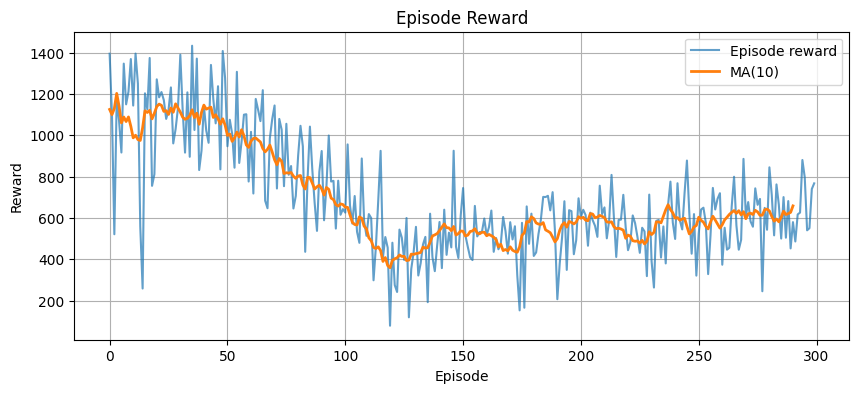

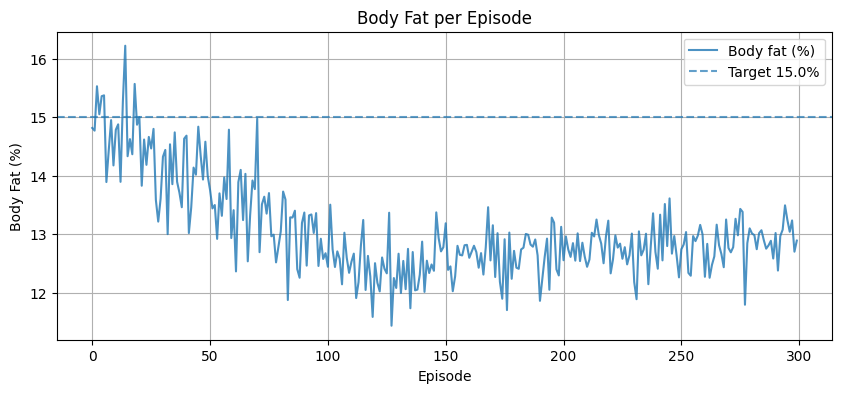

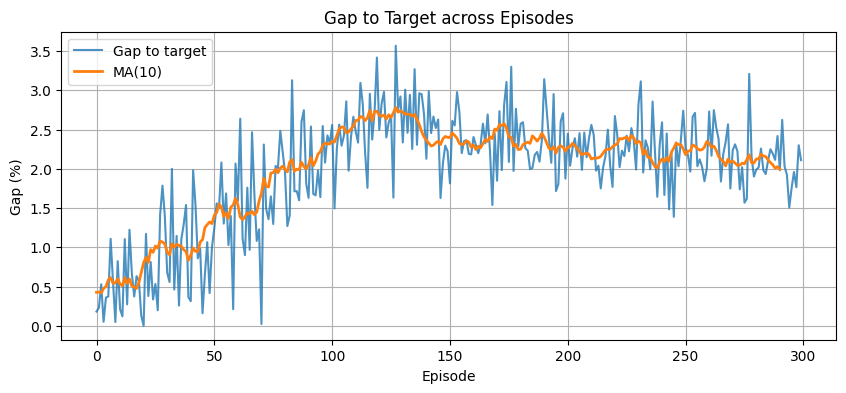

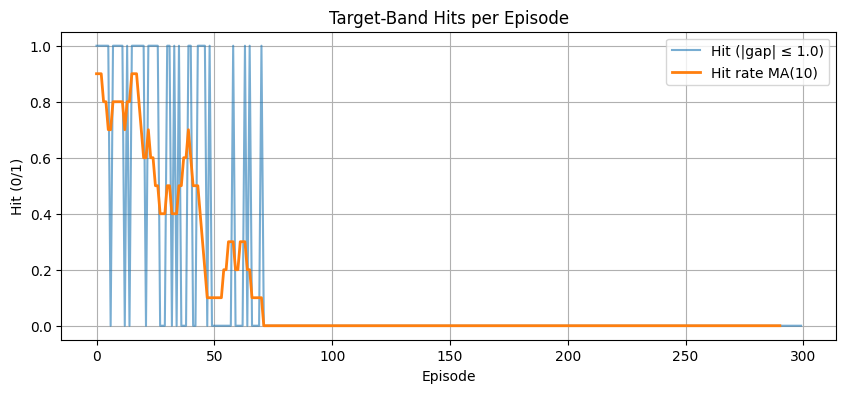

Final 20-ep gap: 2.062
Final 20-ep reward: 646.09
Final 20-ep hit rate (≤ 1.0%): 0.00
Hour 0, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 58.80
Hour 1, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 117.60
Hour 2, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 176.40
Hour 3, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 235.20
Hour 4, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 294.00
Hour 5, Day 0
  Daily Calories Intake: 0.00
  Daily Calories Burned: 352.80
Hour 6, Day 0
  Daily Calories Intake: 600.00
  Daily Calories Burned: 352.80
Hour 7, Day 0
  Daily Calories Intake: 850.00
  Daily Calories Burned: 352.80
Hour 8, Day 0
  Daily Calories Intake: 850.00
  Daily Calories Burned: 628.42
Hour 9, Day 0
  Daily Calories Intake: 1250.00
  Daily Calories Burned: 628.42
Hour 10, Day 0
  Daily Calories Intake: 1250.00
  Daily Calories Burned: 738.67
Hour 11, Day 0
  Daily Calories Intake: 1250.00
  Daily Calories B

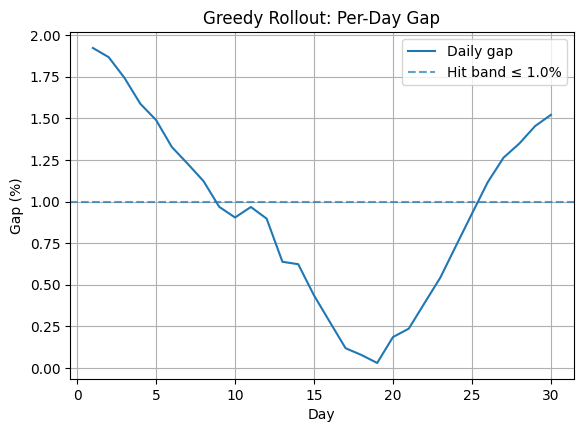

Greedy rollout — mean daily gap: 0.932


In [ ]:
plot_training_curves(env, ep_rewards, ep_body_fat, hit_thresh=1.0)
daily_gap = evaluate_greedy_episode_daily_gap(SchedulerEnv(**profile), agent, threshold=1.0)


In [ ]:
# Cell 1: imports & helpers
import numpy as np
import copy
import gymnasium as gym
from gymnasium import spaces
from typing import Optional, Dict, Any, Tuple, List
import random
from collections import defaultdict, deque
import matplotlib.pyplot as plt

def rolling(x, w=10):
    if len(x) < w:
        return np.asarray(x, dtype=float)
    return np.convolve(x, np.ones(w)/w, mode='valid')


In [ ]:
# Cell 2: SchedulerEnv (improved for cross-person transfer)
class SchedulerEnv(gym.Env):
    def __init__(
        self,
        gender: int = 1,
        age: int = 25,
        height: float = 175.0,
        weight: float = 70.0,
        target_body_fat: float = 15.0,
        days_per_episode: int = 30,
        workloads: float = 1.5,
        sleep_duration: int = 8,
        verbose: bool = False,
        profile_name: str | None = None,   # for logging/optional curriculum
    ):
        super().__init__()
        self.gender = gender
        self.age = age
        self.height = height
        self.weight = weight
        self.target_body_fat = target_body_fat
        self.days_per_episode = days_per_episode
        self.workloads = workloads
        self.sleep_duration = sleep_duration
        self.verbose = verbose
        self.profile_name = profile_name

        self.hours_per_day = 24
        self.scheduler = ["action"] * self.hours_per_day

        # Sleep 8h ending at 06:00
        wake_up_hour = 6
        sleep_start = (wake_up_hour - self.sleep_duration) % 24
        if sleep_start < wake_up_hour:
            for i in range(sleep_start, wake_up_hour):
                self.scheduler[i] = 'sleep'
        else:
            for i in range(sleep_start, 24):
                self.scheduler[i] = 'sleep'
            for i in range(0, wake_up_hour):
                self.scheduler[i] = 'sleep'

        # Work 10–12, 13–18
        for start, end in [(10, 12), (13, 18)]:
            for i in range(start, end):
                self.scheduler[i] = 'work'

        # Nutrient targets
        self.daily_meal_target = {"fiber": 34, "fat": 0.26, "carbs": 0.56, "protein": 0.18}
        self.daily_total_targets = {"water": 3.7, "calcium": 1000.0, "iron": 8.0, "vitamin_c": 90.0}

        # State
        bf0 = 1.2 * (self.weight / (self.height / 100) ** 2) + 0.23 * self.age - 10.8 * self.gender - 5.4
        self.state = {
            "current_weight": float(self.weight),
            "current_bmi": float(self.weight / (self.height / 100) ** 2),
            "current_body_fat": float(bf0),
            "current_hours": 0,
            "day_of_episode": 0,
            "time_since_last_meal": 0,
            "time_since_last_exercise": 0,
            "body_fat_history": [],
            "daily_calories_burned": 0.0,
            "daily_calories_intake": 0.0,
            "daily_calories": float(self.weight * 24.0),  # maintenance proxy
            "daily_fiber_intake": 0.0,
            "daily_fat_intake": 0.0,
            "daily_carbs_intake": 0.0,
            "daily_protein_intake": 0.0,
            "daily_water_intake": 0.0,
            "daily_calcium_intake": 0.0,
            "daily_iron_intake": 0.0,
            "daily_vitamin_c_intake": 0.0
        }
        # track previous-day BF for progress-based reward
        self.prev_bf_day = float(bf0)
        self.initial_state = copy.deepcopy(self.state)

        # Spaces
        self.action_space = spaces.Discrete(10)
        self.observation_space = spaces.Dict({
            "current_weight":        spaces.Box(30.0, 300.0, shape=(1,), dtype=np.float32),
            "current_bmi":           spaces.Box(15.0, 50.0,  shape=(1,), dtype=np.float32),
            "current_body_fat":      spaces.Box(5.0,  50.0,  shape=(1,), dtype=np.float32),
            "current_hours":         spaces.Discrete(self.hours_per_day),
            "day_of_episode":        spaces.Box(0, self.days_per_episode, shape=(1,), dtype=np.int32),
            "time_since_last_meal":  spaces.Box(0, 24, shape=(1,), dtype=np.int32),
            "time_since_last_exercise": spaces.Box(0, self.days_per_episode*24, shape=(1,), dtype=np.int32),
            "daily_calories_burned": spaces.Box(0.0, 4000.0, shape=(1,), dtype=np.float32),
            "daily_calories_intake": spaces.Box(0.0, 4000.0, shape=(1,), dtype=np.float32),
            "daily_calories":        spaces.Box(500.0, 3000.0, shape=(1,), dtype=np.float32),
            "daily_fiber_intake":    spaces.Box(0.0, 50.0, shape=(1,), dtype=np.float32),
            "daily_fat_intake":      spaces.Box(0.0, 200.0, shape=(1,), dtype=np.float32),
            "daily_carbs_intake":    spaces.Box(0.0, 600.0, shape=(1,), dtype=np.float32),
            "daily_protein_intake":  spaces.Box(0.0, 300.0, shape=(1,), dtype=np.float32),
            "daily_water_intake":    spaces.Box(0.0, 10.0, shape=(1,), dtype=np.float32),
            "daily_calcium_intake":  spaces.Box(0.0, 3000.0, shape=(1,), dtype=np.float32),
            "daily_iron_intake":     spaces.Box(0.0, 50.0, shape=(1,), dtype=np.float32),
            "daily_vitamin_c_intake":spaces.Box(0.0, 500.0, shape=(1,), dtype=np.float32),
        })

    # ---- core API ----
    def _get_obs(self):
        s = self.state
        return {
            "current_weight":        np.array([s["current_weight"]], dtype=np.float32),
            "current_bmi":           np.array([s["current_bmi"]], dtype=np.float32),
            "current_body_fat":      np.array([s["current_body_fat"]], dtype=np.float32),
            "current_hours":         s["current_hours"],
            "day_of_episode":        np.array([s["day_of_episode"]], dtype=np.int32),
            "time_since_last_meal":  np.array([s["time_since_last_meal"]], dtype=np.int32),
            "time_since_last_exercise": np.array([s["time_since_last_exercise"]], dtype=np.int32),
            "daily_calories_burned": np.array([s["daily_calories_burned"]], dtype=np.float32),
            "daily_calories_intake": np.array([s["daily_calories_intake"]], dtype=np.float32),
            "daily_calories":        np.array([s["daily_calories"]], dtype=np.float32),
            "daily_fiber_intake":    np.array([s["daily_fiber_intake"]], dtype=np.float32),
            "daily_fat_intake":      np.array([s["daily_fat_intake"]], dtype=np.float32),
            "daily_carbs_intake":    np.array([s["daily_carbs_intake"]], dtype=np.float32),
            "daily_protein_intake":  np.array([s["daily_protein_intake"]], dtype=np.float32),
            "daily_water_intake":    np.array([s["daily_water_intake"]], dtype=np.float32),
            "daily_calcium_intake":  np.array([s["daily_calcium_intake"]], dtype=np.float32),
            "daily_iron_intake":     np.array([s["daily_iron_intake"]], dtype=np.float32),
            "daily_vitamin_c_intake":np.array([s["daily_vitamin_c_intake"]], dtype=np.float32),
        }

    def _get_info(self):
        s = self.state
        return {
            "body_fat_gap": abs(s["current_body_fat"] - self.target_body_fat),
            "weight_change": s["current_weight"] - self.weight,
            "calories_remain": s["daily_calories_intake"] - s["daily_calories_burned"],
            "calories_needed": s["daily_calories"],
            "current_hour": s["current_hours"],
            "day_progress": f"{s['day_of_episode']} / {self.days_per_episode}",
            "action_mask": self.get_action_mask()
        }

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        self.state = copy.deepcopy(self.initial_state)
        self.state["day_of_episode"] = 0
        self.state["current_hours"] = 0
        self.state["time_since_last_meal"] = 0
        self.state["time_since_last_exercise"] = 0
        self.state["body_fat_history"] = []
        self.prev_bf_day = float(self.state["current_body_fat"])
        return self._get_obs(), self._get_info()

    def get_action_mask(self) -> np.ndarray:
        """Loosen mask at work: allow snack (4), supplement (6), and light exercise (7)."""
        current_activity = self.scheduler[self.state["current_hours"]]
        n = self.action_space.n
        mask = np.zeros(n, dtype=bool)
        mask[0] = True  # idle always allowed

        if current_activity == "sleep":
            return mask  # only idle

        if current_activity == "work":
            for a in (4, 6, 7):
                mask[a] = True
            return mask

        # free time -> everything except idle (to encourage acting)
        mask[:] = True
        mask[0] = False
        return mask

    def update_daily_meal_target(self):
        sdc = self.state["daily_calories"]
        self.daily_meal_target_g = {
            "protein": (self.daily_meal_target["protein"] * sdc) / 4.0,
            "fat":     (self.daily_meal_target["fat"]     * sdc) / 9.0,
            "carbs":   (self.daily_meal_target["carbs"]   * sdc) / 4.0,
            "fiber":   self.daily_meal_target["fiber"]
        }
        return self.daily_meal_target_g

    def update_daily_total_target(self):
        w = self.state["current_weight"]
        water_l = w * 0.035
        calcium_mg = 1000 if self.age < 50 else 1200
        iron_mg = 8 if self.gender == 1 else 18
        vitamin_c_mg = 90 if self.gender == 1 else 75
        self.daily_total_targets = {
            "water": round(water_l, 2),
            "calcium": float(calcium_mg),
            "iron": float(iron_mg),
            "vitamin_c": float(vitamin_c_mg)
        }

    def get_reward(self):
        r = 0.0
        tsm = self.state["time_since_last_meal"]
        if tsm == 0:      r += 0.5
        elif tsm < 2:     r -= 0.5
        elif tsm > 6:     r -= 0.5
        else:             r += 0.2
        if self.state["time_since_last_exercise"] == 0:
            r += 1.0
        return r

    def get_daily_reward(self):
        # Daily energy accounting with maintenance
        intake = self.state["daily_calories_intake"]
        burned = self.state["daily_calories_burned"]
        maintenance = self.state["daily_calories"]
        calories_remain = intake - (burned + maintenance)

        # Weight update
        self.state["current_weight"] += calories_remain / 7700.0

        # Recompute BMI, BF, maintenance for next day
        self.state["current_bmi"] = self.state["current_weight"] / (self.height / 100) ** 2
        self.state["current_body_fat"] = 1.2 * self.state["current_bmi"] + 0.23 * self.age - 10.8 * self.gender - 5.4
        self.state["daily_calories"] = self.state["current_weight"] * 24.0

        reward = 0.0
        # Intake closeness
        cal_diff = abs(intake - maintenance)
        reward += max(0.0, 5.0 - cal_diff / 300.0)
        reward += max(0.0, 3.0 - abs(calories_remain) / 1500.0)

        # Macro balance shaping
        meal_ratio = self.update_daily_meal_target()
        if meal_ratio:
            for k in ["protein", "fat", "carbs"]:
                diff = abs(self.state[f"daily_{k}_intake"] - meal_ratio[k])
                reward -= diff * 0.05
            reward += 2.0

        # Micronutrients shaping
        for key, target in self.daily_total_targets.items():
            intake_k = self.state[f"daily_{key}_intake"]
            diff = abs(intake_k - target)
            reward -= diff / (5 * target)
        reward += 1.0

        if intake < burned - 800:
            reward -= 5.0

        # --- Gap-aware BF shaping (NEW) ---
        cur_bf = self.state["current_body_fat"]
        gap = abs(cur_bf - self.target_body_fat)
        # progress bonus if BF reduced vs start-of-day (scaled more when far)
        progress = max(0.0, self.prev_bf_day - cur_bf)
        booster = min(2.0, 0.5 + gap / max(1.0, self.target_body_fat))  # 0.5..2.0
        reward += 2.0 * booster * progress
        # closeness term, slightly stronger if far
        reward += (5.0 - 2.0 * (gap / max(self.target_body_fat, 1e-6))) * (1.0 + 0.25 * min(gap, 5.0))
        # store for next day
        self.prev_bf_day = float(cur_bf)

        return float(reward)

    def step(self, action: int):
        reward = 0.0
        terminated = False
        truncated = False

        current_hours = self.state["current_hours"]
        schedule_activity = self.scheduler[current_hours]

        # --- mild meal scaling by weight (helps B/C/D, tiny effect on A) ---
        scale_w = (self.state["current_weight"] / 70.0) ** 0.3
        def kcal(x): return x * scale_w

        # Scheduled effects first
        if schedule_activity == "work":
            self.state["daily_calories_burned"] += (self.workloads * self.state["current_weight"] * 3.5 / 200) * 60
        elif schedule_activity == "sleep":
            self.state["daily_calories_burned"] += (0.8 * self.state["current_weight"] * 3.5 / 200) * 60
        else:
            # Action effects during free time
            if action == 1:  # Light meal
                calories = kcal(400)
                self.state["daily_calories_intake"] += calories
                self.state["daily_fiber_intake"] += 5
                self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
                self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
                self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
                self.state["daily_water_intake"]  += 0.3
                self.state["time_since_last_meal"] = 0
            elif action == 2:  # Balanced meal
                calories = kcal(600)
                self.state["daily_calories_intake"] += calories
                self.state["daily_fiber_intake"] += 8
                self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
                self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
                self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
                self.state["daily_water_intake"] += 0.3
                self.state["time_since_last_meal"] = 0
            elif action == 3:  # Heavy meal
                calories = kcal(1000)
                self.state["daily_calories_intake"] += calories
                self.state["daily_fiber_intake"] += 10
                self.state["daily_fat_intake"] += calories * self.daily_meal_target["fat"] / 9
                self.state["daily_carbs_intake"] += calories * self.daily_meal_target["carbs"] / 4
                self.state["daily_protein_intake"] += calories * self.daily_meal_target["protein"] / 4
                self.state["daily_water_intake"] += 0.4
                self.state["time_since_last_meal"] = 0
            elif action == 4:  # High-carb snack
                self.state["daily_calories_intake"] += kcal(250)
                self.state["daily_carbs_intake"] += 50
                self.state["daily_water_intake"] += 0.2
                self.state["time_since_last_meal"] = 0
            elif action == 5:  # High-protein snack
                self.state["daily_calories_intake"] += kcal(200)
                self.state["daily_protein_intake"] += 20
                self.state["daily_water_intake"] += 0.2
                self.state["time_since_last_meal"] = 0
            elif action == 6:  # Supplement
                self.state["daily_calcium_intake"] += 200
                self.state["daily_iron_intake"] += 5
                self.state["daily_vitamin_c_intake"] += 50
                self.state["daily_water_intake"] += 0.2
            elif action == 7:  # Light exercise
                self.state["daily_calories_burned"] += (2.5 * self.state["current_weight"] * 3.5 / 200) * 30
                self.state["time_since_last_exercise"] = 0
            elif action == 8:  # Moderate exercise
                self.state["daily_calories_burned"] += (5.0 * self.state["current_weight"] * 3.5 / 200) * 45
                self.state["time_since_last_exercise"] = 0
            elif action == 9:  # Heavy exercise
                self.state["daily_calories_burned"] += (8.0 * self.state["current_weight"] * 3.5 / 200) * 60
                self.state["time_since_last_exercise"] = 0

        # Hourly shaping
        reward += self.get_reward()

        # Advance time / end-of-day
        if self.state["current_hours"] >= self.hours_per_day - 1:
            reward += self.get_daily_reward()
            self.state["body_fat_history"].append(self.state["current_body_fat"])

            if abs(self.state["current_body_fat"] - self.target_body_fat) < 1.0:
                reward += 50.0
            if self.state["current_body_fat"] < 5.0 or self.state["current_body_fat"] > 40.0:
                reward -= 100.0
                terminated = True

            for key in [
                "daily_calories_burned","daily_calories_intake",
                "daily_protein_intake","daily_fat_intake","daily_carbs_intake","daily_fiber_intake",
                "daily_water_intake","daily_calcium_intake","daily_iron_intake","daily_vitamin_c_intake"
            ]:
                self.state[key] = 0.0

            self.state["current_hours"] = 0
            self.state["day_of_episode"] += 1
            # mark start-of-day BF for next progress comparison
            self.prev_bf_day = float(self.state["current_body_fat"])
        else:
            self.state["current_hours"] += 1

        # Always update timers
        self.state["time_since_last_meal"] += 1
        self.state["time_since_last_exercise"] += 1

        truncated = self.state["day_of_episode"] >= self.days_per_episode
        return self._get_obs(), float(reward), bool(terminated), bool(truncated), self._get_info()

    def action_masks(self) -> np.ndarray:
        return self.get_action_mask()


In [ ]:
# Cell 3: Discretizer + Dyna-Q
class DictObsDiscretizer:
    """
    Discretize observation with normalization to person's BMR proxy (weight*24).
    This makes policies transfer better across body sizes.
    """
    def __init__(self, days_per_episode: int):
        self.days_per_episode = days_per_episode
        self.keys_binned = {
            # keep coarse identity cues
            "current_weight":   np.linspace(50, 90, 13),
            "current_body_fat": np.linspace(8, 30, 12),
            # normalized features (per-BMR)
            "intake_per_bmr":  np.linspace(0.0, 2.0, 16),
            "burn_per_bmr":    np.linspace(0.0, 2.0, 16),
            "net_per_bmr":     np.linspace(-1.5, 1.5, 16),   # (intake - (burn + maintenance)) / BMR
        }

    @staticmethod
    def _scalar(x):
        arr = np.asarray(x)
        return float(arr.item()) if arr.shape == () or arr.size == 1 else float(arr.ravel()[0])

    def _bin_scalar(self, x, edges):
        idx = np.digitize([x], edges)[0]
        return int(np.clip(idx, 0, len(edges)))

    def __call__(self, obs: Dict[str, Any]) -> Tuple[int, ...]:
        s = []
        s.append(int(np.clip(self._scalar(obs["current_hours"]), 0, 23)))
        s.append(int(np.clip(self._scalar(obs["time_since_last_meal"]), 0, 24)))
        s.append(int(np.clip(self._scalar(obs["time_since_last_exercise"]), 0, 7*24)))
        s.append(int(np.clip(self._scalar(obs["day_of_episode"]), 0, self.days_per_episode)))

        w = max(1e-6, self._scalar(obs["current_weight"]))
        bmr = max(1200.0, w * 24.0)

        intake = self._scalar(obs["daily_calories_intake"])
        burned = self._scalar(obs["daily_calories_burned"])
        maint  = self._scalar(obs["daily_calories"])  # maintenance proxy
        intake_per_bmr = intake / bmr
        burn_per_bmr   = burned / bmr
        net_per_bmr    = (intake - (burned + maint)) / bmr

        features = {
            "current_weight":   w,
            "current_body_fat": self._scalar(obs["current_body_fat"]),
            "intake_per_bmr":   intake_per_bmr,
            "burn_per_bmr":     burn_per_bmr,
            "net_per_bmr":      net_per_bmr,
        }
        for k, edges in self.keys_binned.items():
            s.append(self._bin_scalar(features[k], edges))
        return tuple(s)

class DynaQAgent:
    def __init__(
        self,
        n_actions: int,
        discretizer: DictObsDiscretizer,
        alpha: float = 0.2,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.05,
        epsilon_decay_steps: int = 50_000,
        planning_steps: int = 40,
        model_capacity: int = 200_000,
        seed: int = 0,
    ):
        self.n_actions = n_actions
        self.disc = discretizer
        self.alpha = alpha
        self.gamma = gamma
        self.eps_start = epsilon_start
        self.eps_end = epsilon_end
        self.eps_decay = max(1, epsilon_decay_steps)
        self.planning_steps = planning_steps
        self.rng = random.Random(seed)
        np.random.seed(seed)

        self.Q = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float32))
        self.model: Dict[Tuple[Tuple[int, ...], int], Tuple[Tuple[int, ...], float, bool]] = {}
        self.sa_index: List[Tuple[Tuple[int, ...], int]] = []
        self.sa_seen = set()
        self.buffer = deque(maxlen=model_capacity)
        self.total_steps = 0

    def epsilon(self):
        frac = min(1.0, self.total_steps / self.eps_decay)
        return self.eps_start + frac * (self.eps_end - self.eps_start)

    @staticmethod
    def _valid_actions(action_mask, n_actions):
        if action_mask is None:
            return list(range(n_actions))
        return [a for a, ok in enumerate(action_mask) if bool(ok)]

    def act(self, obs, action_mask=None):
        s = self.disc(obs)
        eps = self.epsilon()
        valid = self._valid_actions(action_mask, self.n_actions) or list(range(self.n_actions))
        if self.rng.random() < eps:
            return self.rng.choice(valid)
        q = self.Q[s]
        q_masked = q.copy()
        invalid = set(range(self.n_actions)) - set(valid)
        if invalid:
            q_masked[list(invalid)] = -1e9
        return int(np.argmax(q_masked))

    def _learn(self, s, a, r, s_next, done):
        q = self.Q[s]
        td_target = r if done else r + self.gamma * np.max(self.Q[s_next])
        q[a] += self.alpha * (td_target - q[a])

    def _remember(self, s, a, r, s_next, done):
        self.model[(s, a)] = (s_next, r, done)
        if (s, a) not in self.sa_seen:
            self.sa_seen.add((s, a))
            self.sa_index.append((s, a))
        self.buffer.append((s, a, r, s_next, done))

    def _plan(self):
        for _ in range(self.planning_steps):
            if not self.sa_index:
                return
            s, a = self.rng.choice(self.sa_index)
            s_next, r, done = self.model[(s, a)]
            self._learn(s, a, r, s_next, done)

    def step(self, obs, a, r, next_obs, done):
        s = self.disc(obs)
        s_next = self.disc(next_obs)
        self._learn(s, a, r, s_next, done)
        self._remember(s, a, r, s_next, done)
        self._plan()
        self.total_steps += 1


In [ ]:
# Cell 4: training & eval helpers
def train_dyna_q(env, episodes=300, planning_steps=40, seed=0,
                 alpha=0.25, gamma=0.995, epsilon_end=0.10, epsilon_decay_steps=80_000):
    disc = DictObsDiscretizer(env.days_per_episode)
    agent = DynaQAgent(
        env.action_space.n, disc,
        alpha=alpha, gamma=gamma,
        epsilon_start=1.0, epsilon_end=epsilon_end,
        epsilon_decay_steps=epsilon_decay_steps,
        planning_steps=planning_steps, seed=seed
    )

    ep_rewards, ep_bodyfat = [], []
    for _ in range(episodes):
        obs, info = env.reset()
        mask = info.get("action_mask")
        done = False
        total_r = 0.0
        cap_steps = env.days_per_episode * 24 + 4

        steps = 0
        while not done and steps < cap_steps:
            a = agent.act(obs, mask)
            next_obs, r, term, trunc, next_info = env.step(a)
            agent.step(obs, a, r, next_obs, bool(term or trunc))
            total_r += r
            steps += 1
            obs, mask = next_obs, next_info.get("action_mask")
            done = bool(term or trunc)

        ep_rewards.append(total_r)
        # Body fat at episode end
        bf_scalar = float(np.asarray(obs["current_body_fat"]).ravel()[0])
        ep_bodyfat.append(bf_scalar)

    return agent, np.array(ep_rewards), np.array(ep_bodyfat)

def plot_training_curves(env, rewards, bodyfat, target=None, hit_thresh=1.0):
    if target is None:
        target = getattr(env, "target_body_fat", 18.0)
    gap = np.abs(bodyfat - target)
    hits = (gap <= hit_thresh).astype(float)

    plt.figure(figsize=(10,4))
    plt.plot(rewards, label="Episode reward", alpha=0.7)
    if len(rewards) >= 10:
        plt.plot(rolling(rewards,10), label="MA(10)", linewidth=2)
    plt.xlabel("Episode"); plt.ylabel("Reward"); plt.title("Episode Reward"); plt.grid(True); plt.legend(); plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(bodyfat, label="Body fat (%)", alpha=0.8)
    plt.axhline(target, ls="--", alpha=0.7, label=f"Target {target:.1f}%")
    plt.xlabel("Episode"); plt.ylabel("Body Fat (%)"); plt.title("Body Fat per Episode"); plt.grid(True); plt.legend(); plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(gap, label="Gap to target", alpha=0.8)
    if len(gap) >= 10:
        plt.plot(rolling(gap,10), label="MA(10)", linewidth=2)
    plt.xlabel("Episode"); plt.ylabel("Gap (%)"); plt.title("Gap to Target across Episodes"); plt.grid(True); plt.legend(); plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(hits, label=f"Hit (|gap| ≤ {hit_thresh})", alpha=0.6)
    if len(hits) >= 10:
        plt.plot(rolling(hits,10), label="Hit rate MA(10)", linewidth=2)
    plt.xlabel("Episode"); plt.ylabel("Hit (0/1)"); plt.title("Target-Band Hits per Episode"); plt.grid(True); plt.legend(); plt.show()

    last_k = min(20, len(gap))
    print(f"Final {last_k}-ep gap: {float(np.mean(gap[-last_k:])):.3f}")
    print(f"Final {last_k}-ep reward: {float(np.mean(rewards[-last_k:])):.2f}")
    print(f"Final {last_k}-ep hit rate (≤ {hit_thresh}%): {float(np.mean(hits[-last_k:])):.2f}")

def evaluate_greedy_episode_daily_gap(env, agent, threshold=1.0):
    def greedy_masked_action(agent, obs, mask):
        s = agent.disc(obs)
        q = agent.Q[s]
        valid = list(range(q.size)) if mask is None else [a for a, ok in enumerate(mask) if bool(ok)]
        if not valid: return int(np.argmax(q))
        q_masked = q.copy()
        invalid = set(range(q.size)) - set(valid)
        if invalid: q_masked[list(invalid)] = -1e9
        return int(np.argmax(q_masked))

    obs, info = env.reset()
    mask = info.get("action_mask")
    done = False
    target = getattr(env, "target_body_fat", 18.0)
    daily_gaps = []
    prev_hour = int(obs["current_hours"])

    while not done:
        a = greedy_masked_action(agent, obs, mask)
        next_obs, _, term, trunc, info = env.step(a)
        cur_hour = int(next_obs["current_hours"])
        # detect midnight by 23 -> 0 rollover
        if prev_hour == 23 and cur_hour == 0:
            bf = float(np.asarray(next_obs["current_body_fat"]).ravel()[0])
            daily_gaps.append(abs(bf - target))
        done = bool(term or trunc)
        obs, mask = next_obs, info.get("action_mask")
        prev_hour = cur_hour

    daily_gaps = np.array(daily_gaps)
    days = np.arange(1, len(daily_gaps)+1)
    plt.figure(figsize=(6.5,4.5))
    plt.plot(days, daily_gaps, label="Daily gap")
    plt.axhline(threshold, ls="--", alpha=0.7, label=f"Hit band ≤ {threshold}%")
    plt.xlabel("Day"); plt.ylabel("Gap (%)"); plt.title("Greedy Rollout: Per-Day Gap"); plt.grid(True); plt.legend(); plt.show()
    print(f"Greedy rollout — mean daily gap: {float(daily_gaps.mean() if len(daily_gaps)>0 else np.nan):.3f}")


In [ ]:
# Cell 5: profile & config
profile = dict(
    gender=1,
    age=25,
    height=175.0,
    weight=70.0,
    target_body_fat=15.0,
    days_per_episode=30,
    workloads=1.5,
    sleep_duration=8,
)

best_cfg = dict(
    planning_steps=68,
    alpha=0.2776746564305598,
    gamma=0.995,
    epsilon_end=0.10,
    epsilon_decay_steps=88541,
)

EPISODES = 300
SEED = 0


In [ ]:
# Cell 6: train
env = SchedulerEnv(**profile)
agent, ep_rewards, ep_body_fat = train_dyna_q(
    env,
    episodes=EPISODES,
    planning_steps=best_cfg["planning_steps"],
    seed=SEED,
    alpha=best_cfg["alpha"],
    gamma=best_cfg["gamma"],
    epsilon_end=best_cfg["epsilon_end"],
    epsilon_decay_steps=best_cfg["epsilon_decay_steps"],
)


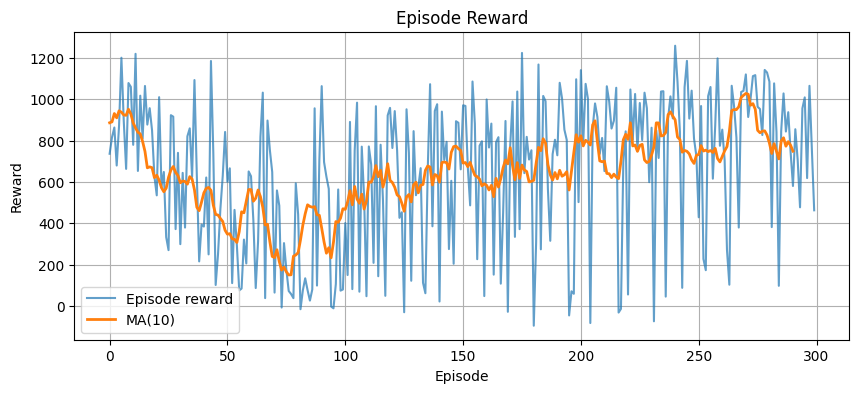

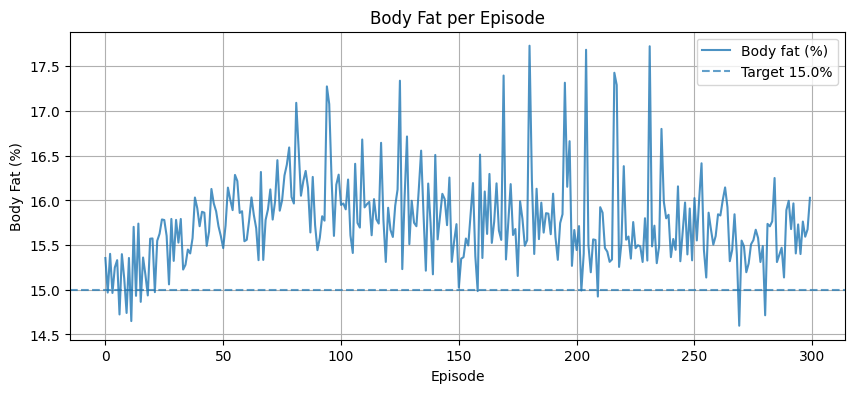

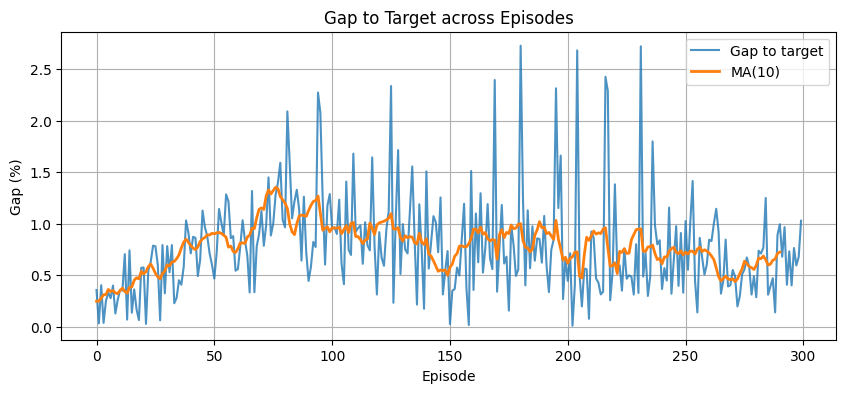

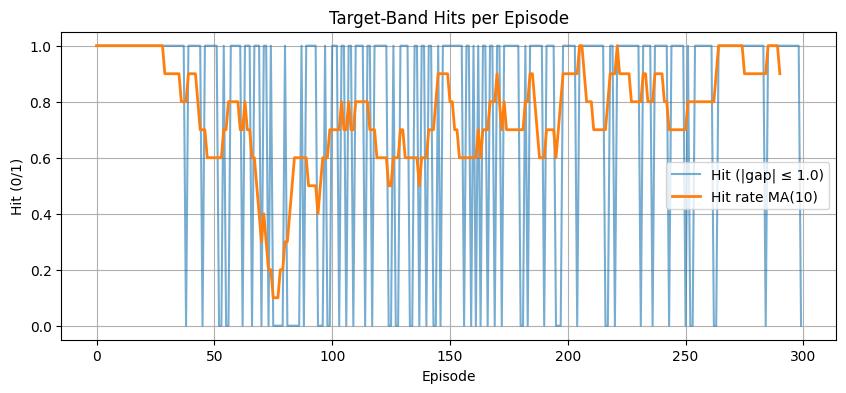

Final 20-ep gap: 0.660
Final 20-ep reward: 768.76
Final 20-ep hit rate (≤ 1.0%): 0.90


In [ ]:
# Cell 7: plots
plot_training_curves(env, ep_rewards, ep_body_fat, hit_thresh=1.0)


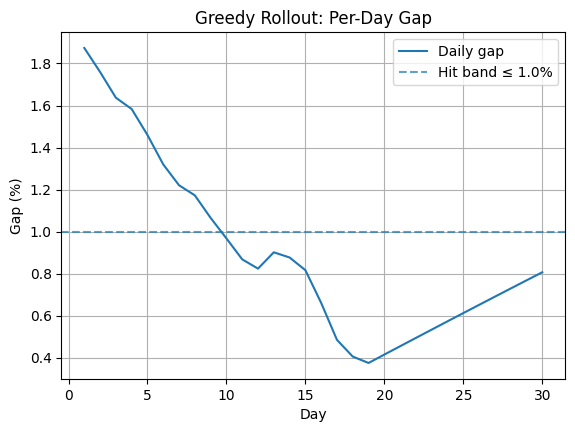

Greedy rollout — mean daily gap: 0.900


In [ ]:
# Cell 8: greedy rollout (fresh env with same profile)
evaluate_greedy_episode_daily_gap(SchedulerEnv(**profile), agent, threshold=1.0)


In [ ]:
# --- Cell: pretty 30-day plan from a trained agent ---

import numpy as np

ACTION_NAMES = {
    0: "idle",
    1: "meal: light (~400 kcal)",
    2: "meal: balanced (~600 kcal)",
    3: "meal: heavy (~1000 kcal)",
    4: "snack: high-carb",
    5: "snack: high-protein",
    6: "supplement",
    7: "exercise: light (≈30min)",
    8: "exercise: moderate (≈45min)",
    9: "exercise: heavy (≈60min)",
}

def _fmt_hour(h): return f"{int(h):02d}:00"

def _greedy_action(agent, obs, mask):
    s = agent.disc(obs)
    q = agent.Q[s]
    valid = list(range(q.size)) if mask is None else [a for a, ok in enumerate(mask) if bool(ok)]
    if not valid:
        return int(np.argmax(q))
    q_mask = q.copy()
    bad = set(range(q.size)) - set(valid)
    if bad:
        q_mask[list(bad)] = -1e9
    return int(np.argmax(q_mask))

def print_multi_day_plan(env, agent, days=30, show_day_headers=True):
    """Greedy rollout for N days; prints lines like '00:00 → rest: deep'."""
    obs, info = env.reset()
    mask = info.get("action_mask")
    lines = []
    day = 1
    prev_hour = int(obs["current_hours"])

    if show_day_headers:
        lines.append(f"— Day {day} —")

    while day <= days:
        h = int(obs["current_hours"])
        sched = env.scheduler[h]  # 'sleep' / 'work' / 'action' / etc.

        if sched == "sleep":
            line = f"{_fmt_hour(h)} → rest: deep"
            a = 0
        elif sched == "work":
            line = f"{_fmt_hour(h)} → work"
            a = 0
        elif sched == "walk":
            line = f"{_fmt_hour(h)} → walk (light)"
            a = 0  # environment already applies walk burn if you use that schedule slot
        else:
            a = _greedy_action(agent, obs, mask)
            line = f"{_fmt_hour(h)} → {ACTION_NAMES.get(a, f'action {a}')}"
        lines.append(line)

        # advance one hour
        obs, _, term, trunc, info = env.step(a)
        if term or trunc:  # episode ended early
            break
        mask = info.get("action_mask")

        # detect midnight rollover (23 -> 0)
        cur_hour = int(obs["current_hours"])
        if prev_hour == 23 and cur_hour == 0:
            day += 1
            if day > days:
                break
            if show_day_headers:
                lines.append(f"\n— Day {day} —")
        prev_hour = cur_hour

    print("\n".join(lines))

# Example usage:
env_for_plan = SchedulerEnv(**profile)
print_multi_day_plan(env_for_plan, agent, days=30)


— Day 1 —
00:00 → rest: deep
01:00 → rest: deep
02:00 → rest: deep
03:00 → rest: deep
04:00 → rest: deep
05:00 → rest: deep
06:00 → supplement
07:00 → exercise: light (≈30min)
08:00 → exercise: moderate (≈45min)
09:00 → snack: high-protein
10:00 → work
11:00 → work
12:00 → exercise: light (≈30min)
13:00 → work
14:00 → work
15:00 → work
16:00 → work
17:00 → work
18:00 → meal: balanced (~600 kcal)
19:00 → meal: light (~400 kcal)
20:00 → meal: light (~400 kcal)
21:00 → exercise: moderate (≈45min)
22:00 → rest: deep
23:00 → rest: deep

— Day 2 —
00:00 → rest: deep
01:00 → rest: deep
02:00 → rest: deep
03:00 → rest: deep
04:00 → rest: deep
05:00 → rest: deep
06:00 → snack: high-protein
07:00 → supplement
08:00 → exercise: heavy (≈60min)
09:00 → exercise: moderate (≈45min)
10:00 → work
11:00 → work
12:00 → meal: light (~400 kcal)
13:00 → work
14:00 → work
15:00 → work
16:00 → work
17:00 → work
18:00 → exercise: moderate (≈45min)
19:00 → meal: light (~400 kcal)
20:00 → meal: light (~400 kcal)

In [ ]:
# --- Collect the FIRST N days from a greedy rollout ---
def collect_first_n_day_plans(env, agent, days=5):
    """
    Returns: list of length `days`.
    Each item: {"day": int, "labels": [24 strings], "actions": [24 ints]}
    """
    obs, info = env.reset()                 # <-- start from day 1
    mask = info.get("action_mask")
    plans = []
    day_idx = 1
    labels, actions = [], []
    prev_hour = int(obs["current_hours"])

    while day_idx <= days:
        h = int(obs["current_hours"])
        sched = env.scheduler[h]

        # choose label + action (greedy, masked)
        if sched == "sleep":
            label, a = "rest: deep", 0
        elif sched == "work":
            label, a = "work", 0
        elif sched == "walk":
            label, a = "walk (light)", 0
        else:
            s = agent.disc(obs)
            q = agent.Q[s]
            valid = list(range(q.size)) if mask is None else [i for i, ok in enumerate(mask) if bool(ok)]
            if not valid:
                a = int(np.argmax(q))
            else:
                q_mask = q.copy()
                bad = set(range(q.size)) - set(valid)
                if bad: q_mask[list(bad)] = -1e9
                a = int(np.argmax(q_mask))
            label = ACTION_NAMES.get(a, f"action {a}")

        labels.append(label); actions.append(a)

        # step one hour
        obs, _, term, trunc, info = env.step(a)
        if term or trunc:                        # episode ended early
            if labels:
                plans.append({"day": day_idx, "labels": labels, "actions": actions})
            break
        mask = info.get("action_mask")

        # detect midnight (23 -> 0): finish the day
        cur_hour = int(obs["current_hours"])
        if prev_hour == 23 and cur_hour == 0:
            plans.append({"day": day_idx, "labels": labels, "actions": actions})
            day_idx += 1
            labels, actions = [], []
        prev_hour = cur_hour

    return plans


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

def plot_day_schedule_from_plan_vertical(plan, title_prefix="Agent Schedule — Day"):
    labels = plan["labels"]

    # optional: shorten very long labels
    pretty = []
    for lbl in labels:
        # break on ": " or space so it wraps nicely on rotation
        s = lbl.replace("≈", "~")  # avoid font issues sometimes
        s = "\n".join(textwrap.fill(s, width=12).split("\n"))  # wrap if needed
        pretty.append(s)

    color_map = {
        "rest: deep": "#1f77b4",
        "work": "#7f7f7f",
        "walk (light)": "#2ca02c",
        "meal: light (~400 kcal)": "#fff2a8",
        "meal: balanced (~600 kcal)": "#ffd84d",
        "meal: heavy (~1000 kcal)": "#ff6b6b",
        "snack: high-carb": "#f4b942",
        "snack: high-protein": "#a6d854",
        "supplement": "#a0c4ff",
        "exercise: light (~30min)": "#66c2a5",
        "exercise: moderate (~45min)": "#32cd32",
        "exercise: heavy (~60min)": "#228b22",
    }
    def color_for(lbl): return color_map.get(lbl, "#cccccc")

    hours = np.arange(24)
    plt.figure(figsize=(14, 3.6))
    for h, lbl in enumerate(labels[:24]):
        plt.bar(h, 1.0, color=color_for(lbl), edgecolor="black")

    # Put vertical text on each bar
    for h, lbl in enumerate(pretty[:24]):
        plt.text(h, 0.03, lbl,
                 ha="center", va="bottom",
                 rotation=90, fontsize=9)

    plt.xlim(-0.5, 23.5)
    plt.ylim(0, 1.10)  # add a little headroom so rotated text isn't clipped
    plt.xticks(range(24))
    plt.yticks([])
    plt.title(f"{title_prefix} {plan.get('day','')}")
    plt.xlabel("Hour of Day")
    plt.tight_layout()
    plt.show()


— Day 1 —
00:00 → rest: deep
01:00 → rest: deep
02:00 → rest: deep
03:00 → rest: deep
04:00 → rest: deep
05:00 → rest: deep
06:00 → supplement
07:00 → exercise: light (≈30min)
08:00 → exercise: moderate (≈45min)
09:00 → snack: high-protein
10:00 → work
11:00 → work
12:00 → exercise: light (≈30min)
13:00 → work
14:00 → work
15:00 → work
16:00 → work
17:00 → work
18:00 → meal: balanced (~600 kcal)
19:00 → meal: light (~400 kcal)
20:00 → meal: light (~400 kcal)
21:00 → exercise: moderate (≈45min)
22:00 → rest: deep
23:00 → rest: deep

— Day 2 —
00:00 → rest: deep
01:00 → rest: deep
02:00 → rest: deep
03:00 → rest: deep
04:00 → rest: deep
05:00 → rest: deep
06:00 → snack: high-protein
07:00 → supplement
08:00 → exercise: heavy (≈60min)
09:00 → exercise: moderate (≈45min)
10:00 → work
11:00 → work
12:00 → meal: light (~400 kcal)
13:00 → work
14:00 → work
15:00 → work
16:00 → work
17:00 → work
18:00 → exercise: moderate (≈45min)
19:00 → meal: light (~400 kcal)
20:00 → meal: light (~400 kcal)

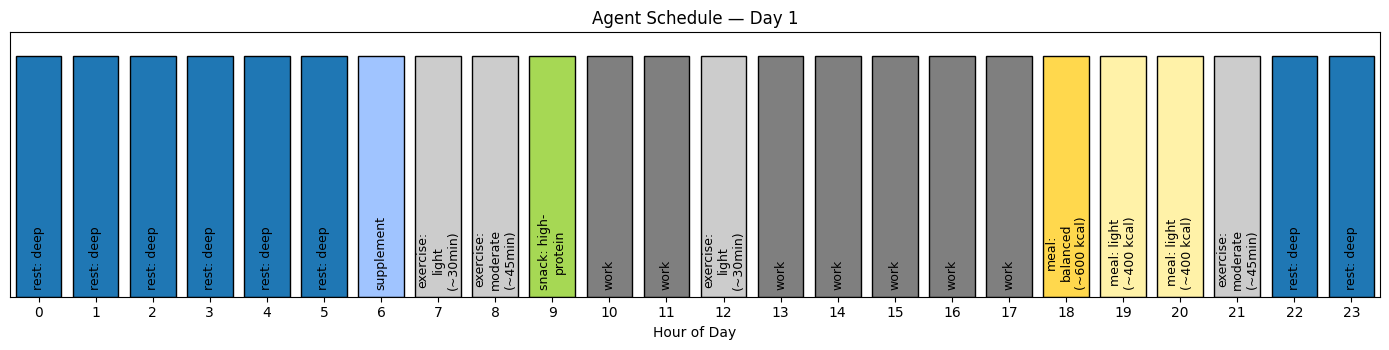

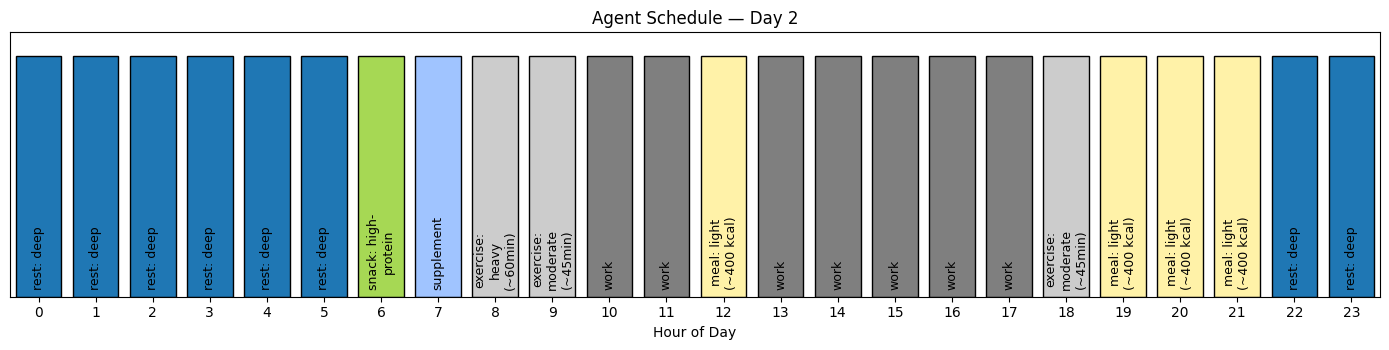

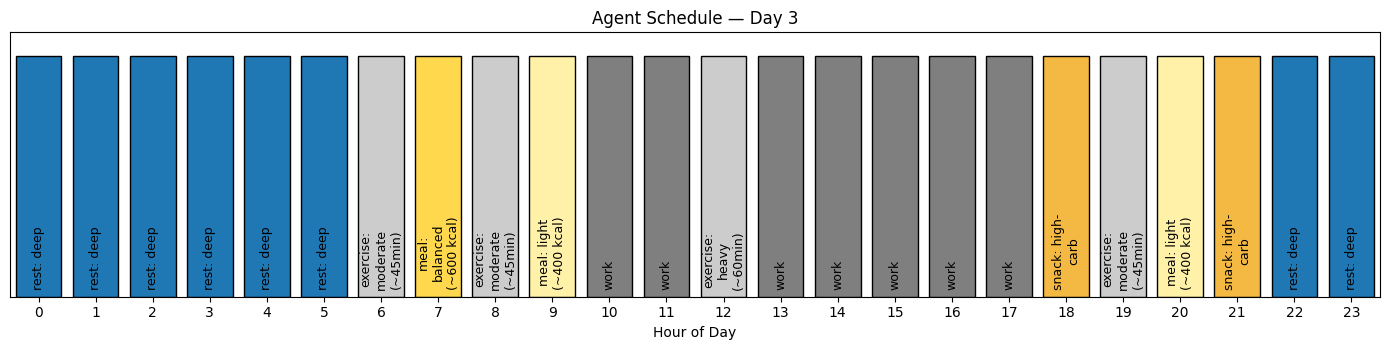

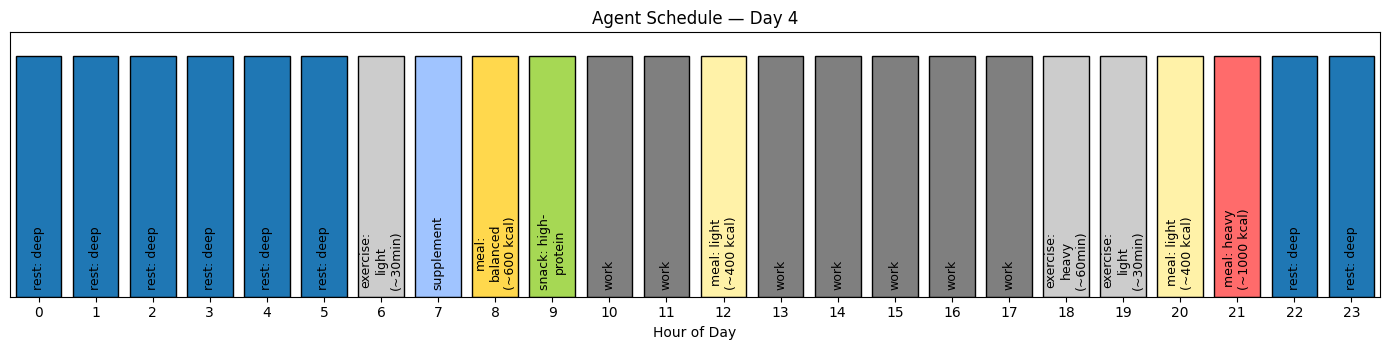

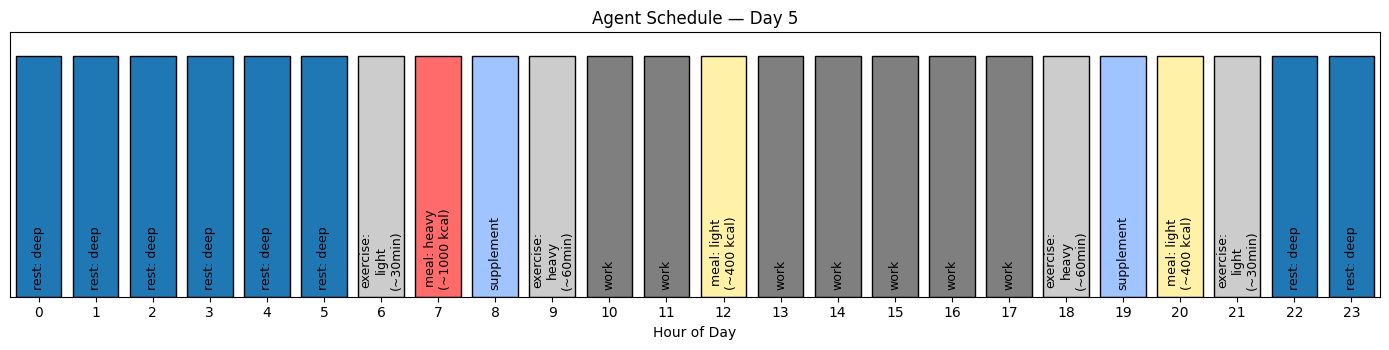

In [ ]:
# Make a fresh env (same profile you trained with)
env_for_plan = SchedulerEnv(**profile)

# Collect the FIRST 5 days
first5_plans = collect_first_n_day_plans(env_for_plan, agent, days=5)

# Print text plans
for p in first5_plans:
    print(f"— Day {p['day']} —")
    for h, lbl in enumerate(p["labels"]):
        print(f"{h:02d}:00 → {lbl}")
    print()

# Plot each of the 5 days as a single-day bar chart
for p in first5_plans:  # or whatever list you collected
    plot_day_schedule_from_plan_vertical(p)

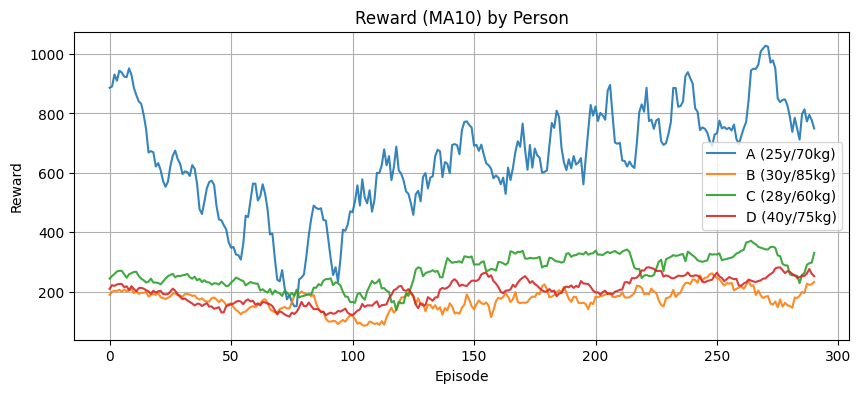

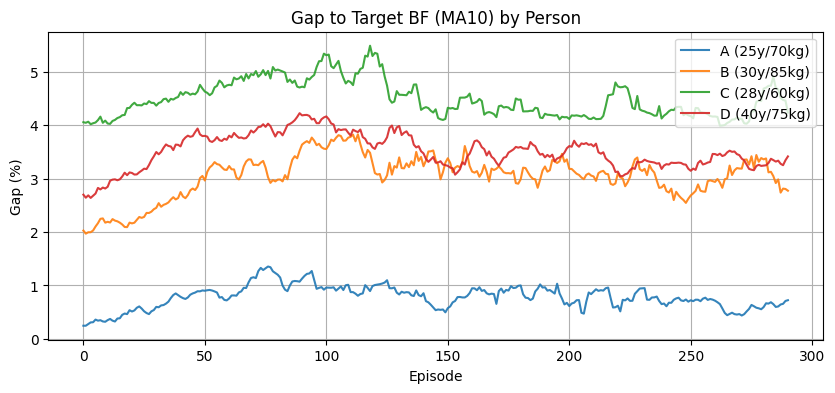

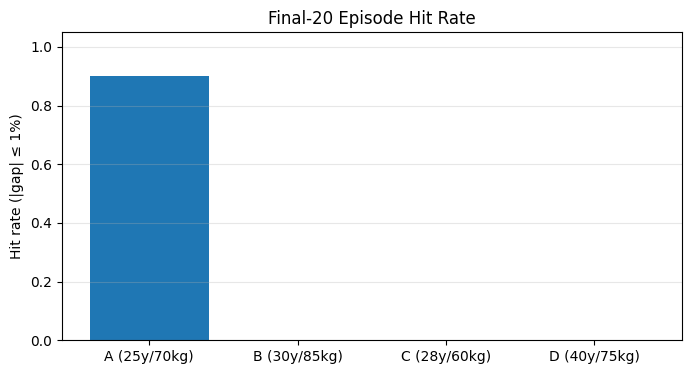

Summary (final-20 episodes)
------------------------------------------------------------
A (25y/70kg)      target=15.0%  gap= 0.66%  hit_rate= 90.0%  reward=  768.8
B (30y/85kg)      target=18.0%  gap= 3.07%  hit_rate=  0.0%  reward=  192.0
C (28y/60kg)      target=22.0%  gap= 4.46%  hit_rate=  0.0%  reward=  294.7
D (40y/75kg)      target=17.0%  gap= 3.33%  hit_rate=  0.0%  reward=  259.2


In [ ]:
# --- Cell: 4-person comparison run ---

import matplotlib.pyplot as plt
import numpy as np

# Reuse your best config
BEST_CFG = dict(
    planning_steps=68,
    alpha=0.2776746564305598,
    gamma=0.995,
    epsilon_end=0.10,
    epsilon_decay_steps=88541,
)

EPISODES = 300
SEED = 0

# Four profiles to compare (feel free to edit)
profiles = [
    dict(name="A (25y/70kg)", gender=1, age=25, height=175.0, weight=70.0, target_body_fat=15.0, days_per_episode=30, workloads=1.5, sleep_duration=8),
    dict(name="B (30y/85kg)", gender=1, age=30, height=180.0, weight=85.0, target_body_fat=18.0, days_per_episode=30, workloads=1.3, sleep_duration=7),
    dict(name="C (28y/60kg)", gender=0, age=28, height=165.0, weight=60.0, target_body_fat=22.0, days_per_episode=30, workloads=1.6, sleep_duration=8),
    dict(name="D (40y/75kg)", gender=1, age=40, height=178.0, weight=75.0, target_body_fat=17.0, days_per_episode=30, workloads=1.2, sleep_duration=7),
]

def rolling(x, w=10):
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")

def train_one(profile):
    env = SchedulerEnv(**{k:v for k,v in profile.items() if k != "name"})
    agent, rewards, bodyfat = train_dyna_q(
        env,
        episodes=EPISODES,
        planning_steps=BEST_CFG["planning_steps"],
        seed=SEED,
        alpha=BEST_CFG["alpha"],
        gamma=BEST_CFG["gamma"],
        epsilon_end=BEST_CFG["epsilon_end"],
        epsilon_decay_steps=BEST_CFG["epsilon_decay_steps"],
    )
    return env, agent, rewards, bodyfat

runs = []
for p in profiles:
    env, agent, rewards, bodyfat = train_one(p)
    target = env.target_body_fat
    gap = np.abs(bodyfat - target)
    k = min(20, len(gap))
    hit_rate = float(np.mean((gap[-k:] <= 1.0)))
    runs.append(dict(profile=p, env=env, agent=agent, rewards=rewards, bodyfat=bodyfat, gap=gap, hit_rate=hit_rate))

# --- plots ---
colors = ["C0","C1","C2","C3"]

# 1) Reward MA(10)
plt.figure(figsize=(10,4))
for i, r in enumerate(runs):
    plt.plot(rolling(r["rewards"], 10), label=f'{r["profile"]["name"]}', alpha=0.9)
plt.title("Reward (MA10) by Person"); plt.xlabel("Episode"); plt.ylabel("Reward"); plt.grid(True); plt.legend(); plt.show()

# 2) Gap-to-target MA(10)
plt.figure(figsize=(10,4))
for i, r in enumerate(runs):
    plt.plot(rolling(r["gap"], 10), label=f'{r["profile"]["name"]}', alpha=0.9)
plt.title("Gap to Target BF (MA10) by Person"); plt.xlabel("Episode"); plt.ylabel("Gap (%)"); plt.grid(True); plt.legend(); plt.show()

# 3) Final-20 hit rate bars
names = [r["profile"]["name"] for r in runs]
hits = [r["hit_rate"] for r in runs]
plt.figure(figsize=(8,4))
plt.bar(names, hits)
plt.ylim(0,1.05); plt.ylabel("Hit rate (|gap| ≤ 1%)"); plt.title("Final-20 Episode Hit Rate"); plt.grid(axis="y", alpha=0.3)
plt.show()

# 4) Print summary table
print("Summary (final-20 episodes)")
print("-"*60)
for r in runs:
    p = r["profile"]
    k = min(20, len(r["gap"]))
    mean_gap = float(np.mean(r["gap"][-k:]))
    mean_rew = float(np.mean(r["rewards"][-k:]))
    print(f'{p["name"]:<16}  target={r["env"].target_body_fat:>4.1f}%  '
          f'gap={mean_gap:>5.2f}%  hit_rate={r["hit_rate"]*100:>5.1f}%  '
          f'reward={mean_rew:>7.1f}')
